# 🏋️ gym — Confidence-Weighted Merge Test (Real Split-MNIST)

This notebook specifically tests the **`confidence-weighted`** merge
strategy against real trained branches — including the scenario it was
actually built for: **one branch trained on much less data than the
other**. Plain averaging treats both branches as equally trustworthy
regardless of how much data backed them; confidence-weighted doesn't.

Two experiments, same real MNIST data both times:

1. **Balanced** — branch A (digits 0–4) vs branch B (digits 5–9), each
   trained on its full real shard (~30k images each). Sizes are close, so
   confidence-weighted should land close to plain averaging here — that's
   the expected sanity check, not a bug.
2. **Imbalanced** — branch A (full shard, ~30k images) vs a deliberately
   starved branch B trained on only **300** real images from its shard.
   This is where the strategies should actually diverge: plain averaging
   still gives the starved branch 50% of the say; confidence-weighted,
   tagged with real dataset sizes at commit time, should weight it far
   less.

If this notebook shows confidence-weighted beating plain averaging on the
imbalanced case specifically, that's a real, citable result — not a
synthetic one.

> ✅ No local installs required — everything runs inside Colab's container.

## ⚙️ Step 0 — Install Node.js 22 (LTS)
Required for `--experimental-transform-types`.

In [1]:
%%bash
curl -fsSL https://deb.nodesource.com/setup_22.x | bash - > /dev/null 2>&1
apt-get install -y nodejs > /dev/null 2>&1
node --version
npm --version

v22.23.2
10.9.8


## 📦 Step 1 — Clone the gym Repository

> **⚠️ IMPORTANT:** make sure the repo you clone includes `confidenceWeighted.ts` and the updated CLI (`--dataset-size`, `--metric`, `--base auto` support) — push those changes before running this notebook if you haven't yet.

In [2]:
import os

# ─── 🔧 CONFIGURE THIS ───────────────────────────────────────────────────────
GITHUB_REPO_URL = "https://github.com/Sakshamvijay-078/gym-gitForLLm"
# ─────────────────────────────────────────────────────────────────────────────

REPO_DIR = "/content/gym"

if os.path.exists(REPO_DIR):
    print("Repo already cloned, pulling latest...")
    os.system(f"cd {REPO_DIR} && git pull")
else:
    ret = os.system(f"git clone {GITHUB_REPO_URL} {REPO_DIR}")
    if ret != 0:
        raise RuntimeError("❌ git clone failed. Check your GITHUB_REPO_URL above.")

print(f"\n✅ Repo ready at {REPO_DIR}")


✅ Repo ready at /content/gym


## 🧪 Step 2 — Run All Unit Smoke Tests
Five suites now — including `confidenceWeighted.smoke.ts`, which includes the
hand-computed case where confidence literally flips the elected sign vs
plain TIES. If that one fails, the real-data numbers below aren't trustworthy.

In [3]:
%%bash
set -e
PACKAGE_DIR="/content/gym/packages/core-versioning"

for f in diskBlobStore manifestStore merge codecs confidenceWeighted; do
  echo "============================================================"
  echo "  Running: $f.smoke.ts"
  echo "============================================================"
  node --experimental-transform-types $PACKAGE_DIR/test/$f.smoke.ts
  echo ""
done

  Running: diskBlobStore.smoke.ts
ok - put() returns a 64-char sha256 hash
ok - get(hash) returns exactly the bytes that were put
ok - exists(hash) is true after put
ok - get() on a missing hash throws BlobNotFoundError
ok - exists() is false for a hash that was never stored
ok - putting identical bytes twice returns the identical hash
ok - dedup: no new object written for identical bytes
ok - different bytes produce a different hash
ok - blob is stored under git-style sharded directory

All checks passed.

  Running: manifestStore.smoke.ts
ok - root manifest commits with parents: []
ok - round 1 manifest correctly points at root as parent
ok - two concurrent commits from the same parent get distinct hashes
ok - round 1 has exactly two children — a real branch, nothing overwritten
ok - log() from branch A walks back 3 manifests: branchA -> round1 -> root
ok - log() returns the chain newest-first in the correct order
ok - the root manifest terminates the chain with parents: []
ok - comm

(node:7911) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:7922) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:7933) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:7944) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)
(node:7951) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


## 🐍 Step 3 — Install Python Dependencies

In [4]:
!pip install safetensors --quiet
import torch, torchvision, safetensors
print(f"✅ torch=={torch.__version__}  torchvision=={torchvision.__version__}  safetensors=={safetensors.__version__}")

✅ torch==2.11.0+cpu  torchvision==0.26.0+cpu  safetensors==0.8.0


## 🔢 Step 4 — Load Real MNIST and Build the Split
Same Split-MNIST setup as the earlier notebook: branch A only ever sees
digits 0–4, branch B only ever sees digits 5–9, from the real MNIST
training set.

In [5]:
import torch
from torch.utils.data import Subset
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

train_full = datasets.MNIST(root="/content/data", train=True, download=True, transform=transform)
test_full  = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

def indices_for_classes(dataset, classes):
    targets = dataset.targets
    mask = torch.isin(targets, torch.tensor(classes))
    return torch.where(mask)[0].tolist()

SHARD_A_CLASSES = [0, 1, 2, 3, 4]
SHARD_B_CLASSES = [5, 6, 7, 8, 9]

shard_a = Subset(train_full, indices_for_classes(train_full, SHARD_A_CLASSES))
shard_b_full = Subset(train_full, indices_for_classes(train_full, SHARD_B_CLASSES))

test_a = Subset(test_full, indices_for_classes(test_full, SHARD_A_CLASSES))
test_b = Subset(test_full, indices_for_classes(test_full, SHARD_B_CLASSES))

# --- the deliberately starved branch: only 300 REAL images from shard B ---
torch.manual_seed(42)
STARVED_SIZE = 300
starved_indices = torch.randperm(len(shard_b_full))[:STARVED_SIZE].tolist()
shard_b_starved = Subset(shard_b_full, starved_indices)

print(f"Shard A (digits 0-4):          {len(shard_a):,} real training images")
print(f"Shard B, full (digits 5-9):    {len(shard_b_full):,} real training images")
print(f"Shard B, STARVED (digits 5-9): {len(shard_b_starved):,} real training images  <-- deliberately tiny")
print(f"Test set A (digits 0-4):       {len(test_a):,} real held-out images")
print(f"Test set B (digits 5-9):       {len(test_b):,} real held-out images")

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 14.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 46.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.41MB/s]


Shard A (digits 0-4):          30,596 real training images
Shard B, full (digits 5-9):    29,404 real training images
Shard B, STARVED (digits 5-9): 300 real training images  <-- deliberately tiny
Test set A (digits 0-4):       5,139 real held-out images
Test set B (digits 5-9):       4,861 real held-out images


## 🏋️ Step 5 — Train Three Real Branches

All three start from the exact same random init (the root checkpoint):

- **branch_a** — trained on the full real shard A (~30k images)
- **branch_b_full** — trained on the full real shard B (~30k images) — the "balanced" partner for branch_a
- **branch_b_starved** — trained on only 300 real images from shard B — the "imbalanced" partner for branch_a

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader
from safetensors.torch import save_file, load_file

torch.manual_seed(0)

class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(torch.relu(self.fc1(x)))

def train_on_shard(model, dataset, epochs=3, lr=1e-3, batch_size=128):
    loader = DataLoader(dataset, batch_size=min(batch_size, len(dataset)), shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in loader:
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * x.size(0)
        print(f"  epoch {epoch+1}/{epochs}  avg loss {total_loss/len(dataset):.4f}")
    return model

def save_model(model, path):
    state = {k: v.contiguous() for k, v in model.state_dict().items()}
    save_file(state, path)
    print(f"saved {path}")

os.chdir("/content")

root = TinyMLP()
save_model(root, "root.safetensors")

print("\nTraining branch_a on FULL shard A...")
branch_a = TinyMLP()
branch_a.load_state_dict(root.state_dict())
train_on_shard(branch_a, shard_a)
save_model(branch_a, "branch_a.safetensors")

print("\nTraining branch_b_full on FULL shard B...")
branch_b_full = TinyMLP()
branch_b_full.load_state_dict(root.state_dict())
train_on_shard(branch_b_full, shard_b_full)
save_model(branch_b_full, "branch_b_full.safetensors")

print(f"\nTraining branch_b_starved on only {STARVED_SIZE} images from shard B...")
branch_b_starved = TinyMLP()
branch_b_starved.load_state_dict(root.state_dict())
train_on_shard(branch_b_starved, shard_b_starved, epochs=5)  # a few extra epochs since there's so little data
save_model(branch_b_starved, "branch_b_starved.safetensors")

print("\n✅ All real checkpoints exported")

saved root.safetensors

Training branch_a on FULL shard A...
  epoch 1/3  avg loss 0.3159
  epoch 2/3  avg loss 0.1023
  epoch 3/3  avg loss 0.0808
saved branch_a.safetensors

Training branch_b_full on FULL shard B...
  epoch 1/3  avg loss 0.4147
  epoch 2/3  avg loss 0.1615
  epoch 3/3  avg loss 0.1234
saved branch_b_full.safetensors

Training branch_b_starved on only 300 images from shard B...
  epoch 1/5  avg loss 2.1944
  epoch 2/5  avg loss 1.9397
  epoch 3/5  avg loss 1.6931
  epoch 4/5  avg loss 1.4788
  epoch 5/5  avg loss 1.2944
saved branch_b_starved.safetensors

✅ All real checkpoints exported


### Sanity check — the starved branch should be measurably worse on its own digits
This accuracy number becomes the `--metric` tag at commit time, and it's
what confidence-weighted uses (alongside dataset size) to decide how much
each branch should count.

In [7]:
@torch.no_grad()
def accuracy(model, dataset, batch_size=256):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    correct, total = 0, 0
    for x, y in loader:
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

acc_a_self = accuracy(branch_a, test_a)
acc_b_full_self = accuracy(branch_b_full, test_b)
acc_b_starved_self = accuracy(branch_b_starved, test_b)

print(f"branch_a on digits 0-4 (its own shard):          {acc_a_self:.2%}")
print(f"branch_b_full on digits 5-9 (its own shard):     {acc_b_full_self:.2%}")
print(f"branch_b_starved on digits 5-9 (its own shard):  {acc_b_starved_self:.2%}   <-- should be noticeably weaker")

branch_a on digits 0-4 (its own shard):          98.27%
branch_b_full on digits 5-9 (its own shard):     96.17%
branch_b_starved on digits 5-9 (its own shard):  69.02%   <-- should be noticeably weaker


## 🚀 Step 6 — gym init + commit, tagging real dataset size and metric

This is the part that actually matters for confidence-weighted: `--dataset-size`
and `--metric` are the REAL numbers from above, not guesses.

In [8]:
%%bash
cd /content
node --experimental-transform-types /content/gym/packages/cli/src/index.ts init


Initialized empty gym repository in /content/.gym


(node:8615) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


In [9]:
import subprocess, json

GYM = "node --experimental-transform-types /content/gym/packages/cli/src/index.ts"
WD  = "/content"
REFS = "/content/.gym/refs.json"

def gym(*args):
    result = subprocess.run(f"{GYM} {' '.join(str(a) for a in args)}", shell=True, cwd=WD, capture_output=True, text=True)
    print(result.stdout + result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"gym command failed: gym {' '.join(str(a) for a in args)}")
    return result.stdout + result.stderr

def read_hash(node_id: str) -> str:
    with open(REFS) as f:
        refs = json.load(f)
    h = refs["nodes"].get(node_id)
    if not h:
        raise RuntimeError(f"no commit recorded for node '{node_id}'")
    return h

print("--- commit root ---")
gym("commit", "--file", "root.safetensors", "--node", "seed", "--round", "0")
ROOT_HASH = read_hash("seed")

print("--- commit branch_a (tagged with REAL dataset size + metric) ---")
gym("commit", "--file", "branch_a.safetensors", "--node", "nodeA", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", len(shard_a), "--metric", f"{acc_a_self:.4f}")
HASH_A = read_hash("nodeA")

print("--- commit branch_b_full (balanced partner) ---")
gym("commit", "--file", "branch_b_full.safetensors", "--node", "nodeB_full", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", len(shard_b_full), "--metric", f"{acc_b_full_self:.4f}")
HASH_B_FULL = read_hash("nodeB_full")

print("--- commit branch_b_starved (imbalanced partner, tiny real dataset size) ---")
gym("commit", "--file", "branch_b_starved.safetensors", "--node", "nodeB_starved", "--round", "1",
    "--parent", ROOT_HASH, "--dataset-size", STARVED_SIZE, "--metric", f"{acc_b_starved_self:.4f}")
HASH_B_STARVED = read_hash("nodeB_starved")

print(f"\n🔑 root         : {ROOT_HASH}")
print(f"🔑 branch A      : {HASH_A}   (size={len(shard_a)}, metric={acc_a_self:.4f})")
print(f"🔑 branch B full : {HASH_B_FULL}   (size={len(shard_b_full)}, metric={acc_b_full_self:.4f})")
print(f"🔑 branch B starv: {HASH_B_STARVED}   (size={STARVED_SIZE}, metric={acc_b_starved_self:.4f})")

--- commit root ---
[seed round 0] 6d8e36b318  (parent none — root, format safetensors)
(node:8647) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit branch_a (tagged with REAL dataset size + metric) ---
[nodeA round 1] ecde14666e  (parent 6d8e36b318, format safetensors)
(node:8664) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit branch_b_full (balanced partner) ---
[nodeB_full round 1] 41648d67f4  (parent 6d8e36b318, format safetensors)
(node:8676) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)

--- commit branch_b_starved (imbalanced partner, tiny real dataset size) ---
[nodeB_starved round 1] 42a0aa1f24  (parent 6d8

## 🔀 Step 7 — Run the Merges: Balanced vs Imbalanced, Plain vs Confidence-Weighted

Four merges per pair: `average`, `confidence-weighted` (average mode, no
`--base`), `ties`, `confidence-weighted` (TIES mode, `--base auto`).

In [10]:
def run_merge_set(hash_x, hash_y, label_suffix):
    runs = [
        ("average", []),
        ("confidence-weighted", []),                                    # average mode
        ("ties", ["--trim", "0.5"]),
        ("confidence-weighted", ["--base", "auto", "--trim", "0.5", "--lambda", "1"]),  # TIES mode
    ]
    files = {}
    for strategy, extra in runs:
        mode = "cw-ties" if (strategy == "confidence-weighted" and "--base" in extra) else strategy
        node_id = f"merger_{mode.replace('-','')}_{label_suffix}"
        out_file = f"merged_{mode}_{label_suffix}.safetensors"
        args = ["merge", hash_x, hash_y, "--strategy", strategy, "--node", node_id, "--round", "2", "--out", out_file] + extra
        print(f"\n{'='*60}\n  {label_suffix}: {mode}\n{'='*60}")
        gym(*args)
        files[f"{mode} ({label_suffix})"] = out_file
    return files

print("############ BALANCED: branch A vs branch B full ############")
balanced_files = run_merge_set(HASH_A, HASH_B_FULL, "balanced")

print("\n\n############ IMBALANCED: branch A vs branch B starved (300 images) ############")
imbalanced_files = run_merge_set(HASH_A, HASH_B_STARVED, "imbalanced")

merged_files = {**balanced_files, **imbalanced_files}

############ BALANCED: branch A vs branch B full ############

  balanced: average
[merge:average] 9dd88eac2d  (ecde14666e + 41648d67f4 -> merged_average_balanced.safetensors, safetensors)
(node:8744) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


  balanced: confidence-weighted
[merge:confidence-weighted] ef8065ca68  (ecde14666e + 41648d67f4 -> merged_confidence-weighted_balanced.safetensors, safetensors)
(node:8760) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ...` to show where the warning was created)


  balanced: ties
(auto-detected merge base: 6d8e36b318)
[merge:ties] 5bdec9eef2  (ecde14666e + 41648d67f4 -> merged_ties_balanced.safetensors, safetensors)
(node:8776) ExperimentalWarning: Transform Types is an experimental feature and might change at any time
(Use `node --trace-warnings ..

## 📊 Step 8 — Evaluate Everything on the REAL MNIST Test Set

The number to actually watch: in the **imbalanced** rows, does
`confidence-weighted` score closer to branch A's strength (since it
correctly distrusts the 300-image branch) while `average` gets dragged
around by a branch that barely learned anything?

In [11]:
def load_model(path):
    m = TinyMLP()
    m.load_state_dict(load_file(path))
    return m

results = []
for label, path in [
    ("branch A alone", "branch_a.safetensors"),
    ("branch B full alone", "branch_b_full.safetensors"),
    ("branch B starved alone", "branch_b_starved.safetensors"),
    *merged_files.items(),
]:
    model = load_model(path)
    acc_a = accuracy(model, test_a)
    acc_b = accuracy(model, test_b)
    acc_full = accuracy(model, test_full)
    results.append((label, acc_a, acc_b, acc_full))
    print(f"{label:34s}  digits0-4={acc_a:.2%}  digits5-9={acc_b:.2%}  full={acc_full:.2%}")

branch A alone                      digits0-4=98.27%  digits5-9=0.00%  full=50.50%
branch B full alone                 digits0-4=0.00%  digits5-9=96.17%  full=46.75%
branch B starved alone              digits0-4=0.00%  digits5-9=69.02%  full=33.55%
average (balanced)                  digits0-4=74.26%  digits5-9=69.66%  full=72.02%
confidence-weighted (balanced)      digits0-4=83.54%  digits5-9=57.66%  full=70.96%
ties (balanced)                     digits0-4=46.33%  digits5-9=77.08%  full=61.28%
cw-ties (balanced)                  digits0-4=51.76%  digits5-9=71.69%  full=61.45%
average (imbalanced)                digits0-4=97.66%  digits5-9=0.00%  full=50.19%
confidence-weighted (imbalanced)    digits0-4=98.27%  digits5-9=0.00%  full=50.50%
ties (imbalanced)                   digits0-4=97.98%  digits5-9=0.00%  full=50.35%
cw-ties (imbalanced)                digits0-4=98.15%  digits5-9=0.00%  full=50.44%


### Chart — focus on the imbalanced case, since that's what confidence-weighted was built for

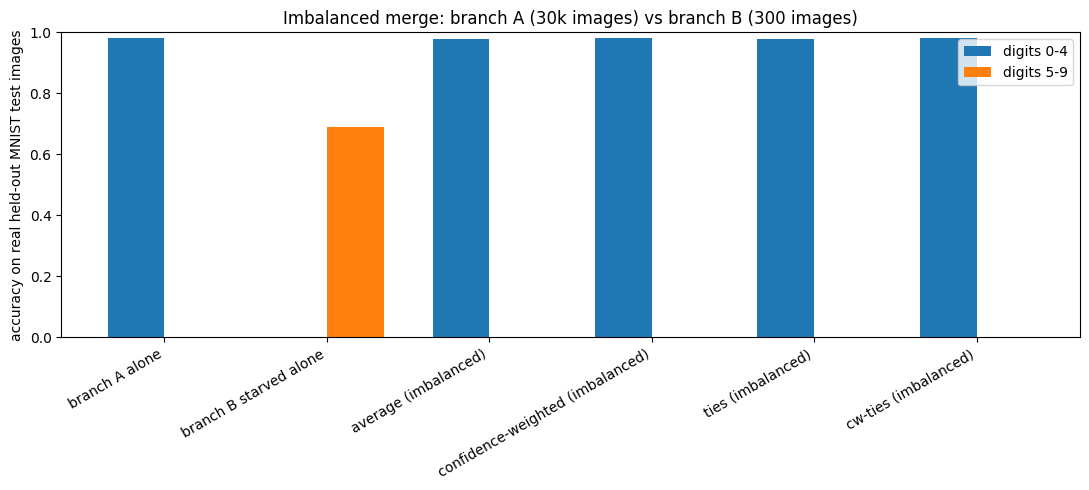


If confidence-weighted correctly distrusts the starved branch, its bars
should sit closer to 'branch A alone' than plain 'average (imbalanced)' does.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

imbalanced_labels = [r[0] for r in results if "(imbalanced)" in r[0] or r[0] == "branch A alone" or r[0] == "branch B starved alone"]
imbalanced_results = [r for r in results if r[0] in imbalanced_labels]

x = np.arange(len(imbalanced_results))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, [r[1] for r in imbalanced_results], width, label="digits 0-4")
ax.bar(x + width/2, [r[2] for r in imbalanced_results], width, label="digits 5-9")
ax.set_ylabel("accuracy on real held-out MNIST test images")
ax.set_title("Imbalanced merge: branch A (30k images) vs branch B (300 images)")
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in imbalanced_results], rotation=30, ha="right")
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig("/content/imbalanced_comparison.png", dpi=120)
plt.show()

print("\nIf confidence-weighted correctly distrusts the starved branch, its bars")
print("should sit closer to 'branch A alone' than plain 'average (imbalanced)' does.")

## 🔍 Step 9 — Inspect the `.gym` Object Store

In [13]:
%%bash
find /content/.gym -type f | wc -l
echo "manifests:"
find /content/.gym/manifests -type f 2>/dev/null | wc -l
echo "objects (blobs):"
find /content/.gym/objects -type f 2>/dev/null | wc -l
du -sh /content/.gym/objects 2>/dev/null

25
manifests:
12
objects (blobs):
12
2.4M	/content/.gym/objects


## ✅ Summary

| Scenario | Branch sizes | What to look for |
|---|---|---|
| Balanced | ~30k vs ~30k | confidence-weighted ≈ plain average/ties — expected, not a bug |
| Imbalanced | ~30k vs 300 | confidence-weighted should sit closer to branch A alone than plain averaging does |

**What this actually proves, if the imbalanced chart shows separation:**
confidence-weighted isn't just a relabeled average — tagging real dataset
size and validation metric at commit time changes the merged model's real,
measured accuracy on held-out data, in the direction you'd want (trust the
branch that actually learned something).

**Honest caveat:** with only 2 branches this is a single data point, not a
statistically rigorous claim. Repeating this with several random
`STARVED_SIZE` draws (or several starved-fraction levels: 300, 1000, 5000,
15000) and plotting the gap between `average` and `confidence-weighted` as
a function of imbalance would turn this into something you could put a
trend line on for your BTP write-up.